In [34]:
fruits_360 = "/kaggle/input/datasets/moltean/fruits/fruits-360_original-size/fruits-360-original-size"
freiburg = "/kaggle/input/datasets/mayarmohamedswilam/freiburg-groceries/images"

In [35]:
import os
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder

In [36]:
# training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

# validation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [37]:
# ---- Dataset + split ----
full_dataset = ImageFolder(root=freiburg, transform=train_transform)
num_classes = len(full_dataset.classes)
print(f"Classes ({num_classes}): {full_dataset.classes}")

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

# val_ds currently shares train_transform (augmented) via full_dataset — override it
# so validation images are evaluated cleanly, not with random augmentation applied.
val_ds.dataset = ImageFolder(root=freiburg, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

Classes (25): ['BEANS', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'FISH', 'FLOUR', 'HONEY', 'JAM', 'JUICE', 'MILK', 'NUTS', 'OIL', 'PASTA', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'TEA', 'TOMATO_SAUCE', 'VINEGAR', 'WATER']


In [38]:
class GroceryCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 224 -> 112
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 112 -> 56
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),# 56 -> 28
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = GroceryCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

cuda


In [39]:
# ---- Training loop ----
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

In [40]:
num_epochs = 20
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion, device)
    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train loss {train_loss:.3f} acc {train_acc:.3f} | "
          f"Val loss {val_loss:.3f} acc {val_acc:.3f}")

Epoch 1/20 | Train loss 2.902 acc 0.164 | Val loss 2.689 acc 0.223
Epoch 2/20 | Train loss 2.677 acc 0.217 | Val loss 2.544 acc 0.277
Epoch 3/20 | Train loss 2.531 acc 0.251 | Val loss 2.463 acc 0.277
Epoch 4/20 | Train loss 2.432 acc 0.276 | Val loss 2.378 acc 0.303
Epoch 5/20 | Train loss 2.331 acc 0.307 | Val loss 2.310 acc 0.324
Epoch 6/20 | Train loss 2.224 acc 0.338 | Val loss 2.276 acc 0.343
Epoch 7/20 | Train loss 2.157 acc 0.359 | Val loss 2.281 acc 0.324
Epoch 8/20 | Train loss 2.100 acc 0.372 | Val loss 2.156 acc 0.348
Epoch 9/20 | Train loss 2.015 acc 0.394 | Val loss 2.225 acc 0.349
Epoch 10/20 | Train loss 1.970 acc 0.415 | Val loss 1.981 acc 0.410
Epoch 11/20 | Train loss 1.886 acc 0.448 | Val loss 1.876 acc 0.453
Epoch 12/20 | Train loss 1.815 acc 0.470 | Val loss 1.809 acc 0.483
Epoch 13/20 | Train loss 1.749 acc 0.493 | Val loss 1.777 acc 0.486
Epoch 14/20 | Train loss 1.702 acc 0.497 | Val loss 1.709 acc 0.521
Epoch 15/20 | Train loss 1.659 acc 0.515 | Val loss 1.638

Index: 851
True class: CHOCOLATE
Predicted class: COFFEE (confidence: 39.76%)
Correct: False


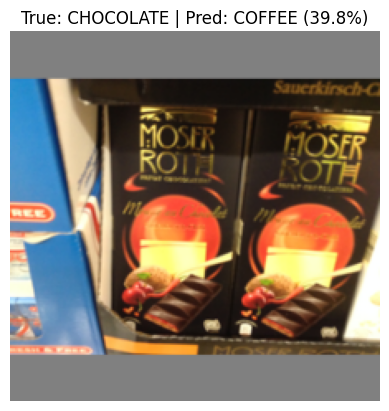

In [50]:
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F

# ---- Pick a RANDOM image from the validation set ----
idx = random.randint(0, len(val_ds) - 1)
img_tensor, true_label = val_ds[idx]

model.eval()
with torch.no_grad():
    img_batch = img_tensor.unsqueeze(0).to(device)
    logits = model(img_batch)
    probs = F.softmax(logits, dim=1)
    pred_label = logits.argmax(1).item()
    confidence = probs[0, pred_label].item()

class_names = full_dataset.classes
true_class = class_names[true_label]
pred_class = class_names[pred_label]

print(f"Index: {idx}")
print(f"True class: {true_class}")
print(f"Predicted class: {pred_class} (confidence: {confidence:.2%})")
print(f"Correct: {pred_class == true_class}")

plt.imshow(img_tensor.permute(1, 2, 0))
plt.title(f"True: {true_class} | Pred: {pred_class} ({confidence:.1%})")
plt.axis("off")
plt.show()